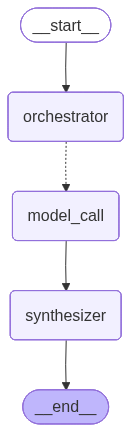

# 引言

## 背景

近年来，大规模语言模型（Large Language Models，LLMs）在自然语言处理领域取得了突破性进展。从早期的统计语言模型到基于Transformer架构的深度神经网络，模型规模的持续扩大推动了性能的显著提升。GPT系列、BERT、LLaMA等模型的成功实践表明，增加参数量、训练数据量和计算资源能够带来更加丰富的语言理解与生成能力。然而，模型规模的扩张并非无止境——训练成本、推理效率、数据获取等问题逐渐凸显，促使研究者系统性地探讨规模与性能之间的内在规律。

## 研究动机

缩放定律（Scaling Laws）的研究旨在揭示模型性能与规模参数（如参数量、数据量、计算预算）之间的定量关系。其核心动机包括：

- **预测性指导**：通过建立数学关系，研究者可以在训练大规模模型前预测其性能表现，优化资源分配。
- **效率边界探索**：理解不同资源维度的收益递减点，避免盲目增大规模而导致浪费。
- **范式转移**：缩放定律的发现推动了“规模即能力”的认知，促使行业集中资源建设超大模型，并激发了数据、架构、训练方法的协同优化。
- **科学解释**：为机器学习中的“涌现行为”提供量化视角，帮助解释为何更大的模型能展现更复杂的推理与泛化能力。

## 重要意义

缩放定律在大语言模型的发展中具有里程碑式的意义。首先，它为模型设计提供了可量化的决策依据——例如，在固定计算预算下，应优先增加参数量还是数据量。其次，它揭示了语言模型能力提升的边界条件，推动研究者从单纯扩大规模转向更均衡的资源配置，如改进数据质量、优化训练策略。此外，缩放定律的普适性预示着其可能成为评估未来新型架构（如混合模型、稀疏激活网络）的基准框架。最终，这些规律不仅指导了当前大模型的部署，也为通向通用人工智能的路径提供了关键理论基石。

---

### 缩放定律的基本概念

缩放定律（Scaling Laws）是描述机器学习模型性能随关键资源配置增加而变化的经验规律，其核心在于明确模型规模、数据规模与计算量三个维度如何共同影响模型最终的表现。这些维度构成了推动模型能力提升的三角基石。

**模型规模**通常指模型中的可训练参数量（Parameters）。更大的模型拥有更多的层数、更宽的隐藏层或更复杂的结构，理论上具备更强的表示能力，能够捕捉更精细的数据模式。然而，参数量并非孤立起效，其收益存在边际递减点，且与数据及计算资源高度耦合。

**数据规模**指用于训练模型的数据集大小（通常以Token数或样本数计量）。充足且高质量的数据是模型学习泛化知识的前提：数据规模不足时，模型易过拟合；数据规模充分时，模型能利用大容量发掘统计规律。数据与模型规模需保持平衡，避免一方成为瓶颈。

**计算量**则代表训练过程中的总浮点运算次数（FLOPs），它综合了模型规模、数据规模与训练步数的影响。计算量直接对应了训练耗时与硬件成本，是实际约束中最具操作性的指标。缩放定律表明，在固定计算预算下，模型规模与数据规模的最优分配存在特定的幂律关系，过度扩大其中一维而忽视另一维将导致效率下降。

这三个维度相互制约：增大模型规模需要等比例增加数据量以避免过拟合，而总计算量则从全局限制了两者的可行组合。理解这一三角关系，是后续讨论缩放定律具体公式、临界点及工程实现的基础。

---

### 核心发现与经验公式

缩放定律的核心贡献在于揭示了大语言模型性能（以损失函数度量）与三个关键缩放因子——模型参数量（N）、训练数据规模（D）和计算预算（C）——之间存在可量化的幂律关系。这些关系不仅具有重要的理论意义，更为模型训练的资源分配与工程实践提供了明确的指导。

**1. 损失函数与模型参数量的关系**

在其他因素固定（特别是数据规模足够大且训练步数充分）的情况下，模型在验证集上的交叉熵损失 L 随参数量 N 的增加而呈现近似幂律衰减。该关系可经验性地描述为：

\[
L(N) \approx \left( \frac{N_c}{N} \right)^{\alpha_N}
\]

其中，\( N_c \) 为与任务相关的常数，\(\alpha_N \approx 0.07\) 至 \(0.10\)（具体值因模型架构与数据分布略有差异）。这表明增加参数量在初期能迅速降低损失，但随着参数量的持续扩大，收益会逐渐递减。

**2. 损失函数与训练数据规模的关系**

同样地，在模型容量固定且训练步数足够时，验证损失随训练数据量 D 的增加也遵循类似的幂律衰减：

\[
L(D) \approx \left( \frac{D_c}{D} \right)^{\alpha_D}
\]

式中 \( D_c \) 为数据相关常数，\(\alpha_D \approx 0.05\) 至 \(0.095\)。该公式说明增加训练数据量同样能持续降低损失，但边际效益递减。这一发现对“数据是否越多越好”的问题给出了定量的回答。

**3. 损失函数与计算预算的关系**

计算预算 C（通常以 FLOPs 度量）与损失之间的关系是最综合的结论，因为它隐含了模型参数量与数据量之间的最优分配。在固定总计算预算下，当参数量 N 和数据量 D 根据计算预算最优分配时，验证损失满足：

\[
L(C) \approx \left( \frac{C_c}{C} \right)^{\alpha_C}
\]

其中，\(\alpha_C \approx 0.05\) 至 \(0.1\)。更关键的是，该关系揭示了计算预算的最优分配比例：预算增量的大约 73% 应分配给增大模型参数量，约 27% 应分配给增加训练数据量。任何偏离这一比例的做法，都会导致在同样计算预算下取得更差的损失。

**4. 综合形式与关键常数**

将上述关系统一在一个公式中，可得到计算最优的缩放行为：

\[
L(N, D) = \frac{A}{N^{\alpha}} + \frac{B}{D^{\beta}} + L_0
\]

其中，\( L_0 \) 为 irreducable loss（不可约损失），代表数据集的固有熵；系数 A、B 为数据与模型相关的比例常数；\(\alpha\)、\(\beta\) 为幂律指数。当参数与数据满足最优比例 \( N \propto C^{\phi} \) 且 \( D \propto C^{1-\phi} \)（\(\phi \approx 0.73\)）时，损失函数简化为仅与计算预算相关的幂律形式。这些数学表达为预测更大规模模型的性能、指导资源分配提供了坚实的经验基础。

---

## 数据缩放与模型缩放的协同

### 数据量与模型参数量的平衡关系

在深度学习与大规模机器学习中，数据量与模型参数量并非独立变量，而是存在深度耦合的平衡关系。这种平衡关系受到“容量—复杂度—泛化”三角制约：

- **模型容量**：由参数量直接决定，参数越多，模型表达能力越强，但过高的容量在数据有限时容易导致过拟合。
- **数据复杂度**：取决于数据规模、噪声水平和任务内在维度。更多数据通常可支持更大模型，但边际收益递减。
- **泛化界限**：理论表明，为保证泛化误差不增加，模型参数量应与数据量保持近似线性增长。例如，经验风险最小化下，为达到相同泛化误差，参数量每增加k倍，数据量通常需增加O(k)量级。

实际中，训练损失与验证损失的变化揭示了这种平衡：当数据量固定时，盲目增加参数会导致验证损失先降后升（泛化鸿沟）；而当参数固定时，增加数据量可使验证损失持续下降直至平台。因此，最优平衡点出现在“数据量约等于参数量乘以某个任务相关常数”附近。

### 计算最优分配原则

给定有限的计算预算（如FLOPs限制、GPU时长或训练轮数），如何分配资源给数据扩容与模型扩容以实现最低泛化损失？该问题可形式化为优化问题：

设**计算代价函数**为 C(D, P) ，其中D为数据样本量，P为参数量。常见假设下，单次训练计算量与 DP 成正比（前向+反向传播），故 C ≈ α · D · P ，α为常数。目标是在固定C下最小化测试损失 L( D, P ) 。

根据神经尺度律的经验公式：

\[
L(D, P) = L_\infty + \frac{a}{D^\alpha} + \frac{b}{P^\beta}
\]

其中 a, b, α, β > 0。则最优分配满足边际相等原则：

\[
\frac{\partial L}{\partial D} \cdot \frac{\partial D}{\partial C} = \frac{\partial L}{\partial P} \cdot \frac{\partial P}{\partial C}
\]

代入 C = α D P 的约束，可得：

\[
\frac{a \alpha}{D^{\alpha+1} P} = \frac{b \beta}{P^{\beta+1} D}
\]

简化后得到**最优数据参数比**：

\[
\frac{D}{P} = \left( \frac{a \alpha}{b \beta} \right)^{\frac{1}{\alpha - \beta}}
\]

当 α=β 时，从式中可解出在固定计算预算下 D 与 P 的最优比例为一常数，即 D / P 固定；当 α ≠ β 时，最优比例随预算大小增加而偏移——数据缩放或模型缩放应当向弹性更大的那一端倾斜。

在实践中，计算最优分配原则引导算法设计者和系统工程师采取“联合缩放”策略：在增大模型参数量的同时，按统一比例增加数据量，或根据实际学习曲线动态调整两者比例，使计算预算分配在帕累托前沿上。这一原则已在 GPT、LLaMA 等大语言模型的训练中得到验证：在不增加额外计算负担前提下，恰当的数据-模型联合缩放可大幅提升模型最终性能。

---

### 缩放定律的实证研究

#### OpenAI的初步发现（Scaling Laws for Neural Language Models）

OpenAI在2020年的工作中系统性地研究了Transformer语言模型在交叉熵损失下的性能如何随模型参数数量、数据集大小以及计算量（FLOPs）的变化而变化。核心发现包括：

- **幂律关系**：测试损失与模型参数量（N）、数据集token数（D）之间呈现平滑的幂律缩放关系，即 \( L \propto N^{-\alpha} \) 和 \( L \propto D^{-\beta} \)，其中 \(\alpha\) 和 \(\beta\) 为常数（约0.076和0.095）。
- **计算最优分配**：在固定计算预算（FLOPs）下，存在最优的模型大小与训练数据量配比。若模型过大而数据不足，则会出现欠拟合；反之则计算浪费。其比例近似为 \( N_{opt} \propto C^{0.73} \)，\( D_{opt} \propto C^{0.27} \)。
- **可预测性**：小规模实验下的性能可外推至大规模，从而指导资源分配和超参数选择。

#### DeepMind的验证与扩展（Training Compute-Optimal Large Language Models）

DeepMind在2022年进一步验证并扩展了缩放定律，关键实证结果如下：

- **验证计算最优分配**：通过分析超过400个模型（参数量从70M到16B不等），DeepMind确认了计算最优训练的幂律关系，但指出OpenAI的原始比例（\( N \propto C^{0.73} \)）略有偏差，建议在固定计算预算下应同时缩放模型和数据。
- **Chinchilla最优比例**：DeepMind提出“Chinchilla法则”，即计算最优时，模型参数量与训练token数的比例大致为 \( N_{opt} \approx 20 \times D_{opt} \)（或每参数量对应约20个token）。基于此，他们训练的Chinchilla（70B参数，1.4T token）在相同计算预算下优于Gopher（280B参数，300B token）。
- **修正先前误解**：许多早期大模型（如GPT-3）实际上处于“过参数化”且“欠训练”状态，即使用更多数据训练更小的模型可获得更好性能。

#### Chinchilla实验的具体发现

Chinchilla工作的核心实验设计是固定三种计算预算（约 \( 1e19, 1e20, 1e21 \) FLOPs），然后训练不同大小（参数量）的模型直到收敛。关键结论包括：

- **最优训练数据量**：对于给定参数量 \( N \)，最优的token数 \( D_{opt} \approx 20N \)。例如，7B参数模型约需140B token，而130B参数模型约需2.6T token。
- **性能单调性**：在计算预算固定的情况下，随着模型规模增大，损失先降低后升高，存在明确的最小值点。
- **可迁移性**：缩放定律在不同模型架构（如不同深度、宽度）和不同数据集（如C4、Wikipedia）上均表现一致。

#### 其他关键实证研究

- **Anthropic的Scaling Monosemanticity**：发现稀疏自编码器中的特征数量也遵循缩放定律，且随模型大小增加，可解释特征的数量呈幂律增长。
- **Google的Pathways研究**：在PaLM模型中验证了缩放定律，同时发现“涌现能力”（如算术推理）往往在损失降至特定阈值后突然出现，而非平滑缩放。
- **Meta的Llama系列**：通过采用更长的训练时间（如Llama 2使用2T token），实证上再次确认了“更大的模型配更多数据”的重要性，并指出许多开源模型实际上处于欠训练状态。

---

## 超越缩放定律：涌现能力与局限性

### 1. 缩放定律的边界条件

缩放定律（Scaling Laws）最初在语言模型领域被揭示，其核心观点是：模型性能随参数规模、数据量和计算量的增加而可预测地提升。然而，这一规律并非无限成立，且存在显著的边界条件。首先，缩放定律假设计算资源、数据质量和模型架构保持不变，但现实场景中，这些因素往往相互制约。例如，当模型参数超过百亿级后，单纯增加参数量若无匹配的高质量数据，性能提升会趋于平缓。其次，模型在特定任务上的表现可能遭遇“天花板”——某些能力（如逻辑推理、常识理解）需要超越参数堆叠的范式，依赖架构创新或训练策略优化。因此，缩放定律更适用于“量变”阶段，而“质变”需要其他机制的介入。

### 2. 涌现能力：门槛效应与非线性突破

涌现能力（Emergent Abilities）是缩放定律最引人注目的反例，指模型在参数规模跨越某个阈值后，突然展现出训练目标未明确要求的能力（如多步推理、代码生成）。这种“门槛效应”具有非线性特征：在小模型上几乎无法检测到的能力，在大模型上以跳跃式方式出现。研究发现，涌现能力与任务复杂度、训练数据分布及模型容量密切相关。例如，在算术运算任务中，当参数规模达到数十亿时，模型可能从完全错误突然转到高精度正确，而非渐进提升。这种现象暗示了模型内部表征的“相变”——参数量的累积导致潜在结构重组，使得隐蔽的因果关系或组合模式被有效激活。但需注意，涌现并非万能：它依赖于任务对模型容量的“刚性需求”，且可能只在特定架构下成立。

### 3. 收益递减：大规模扩展的边际效应

与涌现能力相对应，收益递减（Diminishing Returns）揭示了缩放定律的另一面：当模型规模达到一定量级后，每单位参数增加带来的性能提升逐步降低。这种现象在多个维度均能被观察到——首先，在训练损失曲线上，大模型在收敛后期往往出现损失下降减缓；其次，在下游任务评估中，如语言理解或问答任务，额外参数对结果差异的贡献逐渐被噪声或数据偏差掩盖。其根本原因在于，参数增多并未等比例增加有效信息容量：冗余参数可能仅增强了模型对训练数据中表面规律的记忆，而非深层泛化能力。此外，收益递减还与计算成本指数级增长有关，迫使研究者寻求更高效的方法（如稀疏激活、知识蒸馏）以缓解边际效应。

### 4. 小模型缩放规律的差异

小模型（通常参数规模在亿级以下）的缩放行为显著区别于大模型，表现出独特的规律性。首先，小模型因容量有限，难以稳定涌现复杂能力——其性能提升更多依赖于数据量的线性增长，而非参数量或计算量的指数扩展。例如，在BERT规模的模型上，增加训练数据量通常比增加层数带来更可观的收益。其次，小模型对架构和超参数更为敏感：注意力机制的位置、激活函数类型或优化器选择可能造成数个百分点的性能差异，而大模型对这些因素的鲁棒性更强。最后，小模型的缩放规律往往呈现“平台期”特征：在参数规模扩大到特定阈值前，性能增长缓慢，但一旦突破该阈值（如数亿参数），可能迅速进入“拟大模型”状态。这表明小模型与大模型之间存在一个关键过渡区，其边界由任务复杂度、数据多样性与模型容量共同决定。

---

### 缩放定律在计算预算分配中的应用

缩放定律（Scaling Laws）揭示了模型性能与计算量、参数量及数据量之间的幂律关系，为预算分配提供了理论依据。在实践中，需根据可用计算预算（如FLOPs或GPU小时数）平衡模型参数量与训练数据量。例如，假设预算为 \( C \)，则最优配置需满足：
\[
\text{模型参数量} \propto C^{a}, \quad \text{数据量} \propto C^{b}
\]
其中 \( a \) 和 \( b \) 由缩放定律中的指数决定（通常 \( a \approx 0.5 \), \( b \approx 0.5 \)）。若预算有限，应优先增加数据量而非参数，避免过拟合；预算充裕时则同步扩展二者。

**实例**：在训练一个10亿参数的语言模型时，若总预算为 \( 10^{21} \) FLOPs，根据缩放定律，推荐使用约300B tokens的训练数据，而非盲目增加参数至30亿。

### 训练策略优化：基于缩放定律的实践方法

#### 学习率与批大小调整
缩放定律隐含了学习率与批大小的耦合关系。为提升训练效率，可采用以下策略：
- **线性缩放法则**：批大小翻倍时，学习率同步加倍，以维持梯度噪声比稳定。
- **余弦退火调度**：结合总步数动态调整学习率，避免后期震荡。

#### 数据与模型并行调度
在大规模训练中，需权衡数据并行与模型并行的混合使用。缩放定律建议：
- 当模型参数量超过单卡显存时，采用张量并行（Tensor Parallelism）分割参数。
- 将梯度累积步数设为批大小的整数倍，以隐藏通信开销。

#### 提前终止与自适应预算
若训练过程中评估损失提前收敛，可依据缩放定律预测最终性能并动态终止。例如：
- 计算当前损失 \( L(t) \) 与理论拟合值 \( \hat{L}(t) = \alpha t^{-\beta} \) 的偏差。
- 当 \( |L(t) - \hat{L}(t)| < \epsilon \) 持续10步时，提前停止以节省计算资源。

### 部署优化：从缩放定律到推理效率

#### 模型压缩的缩放指导
缩放定律表明，小模型在低延迟场景中更高效。部署时可通过剪枝或量化降低参数量，同时保证性能损失可控：
- **结构化剪枝**：移除注意力头或隐藏层，若贡献度低于阈值（如缩放定律中定义的重要性系数）。
- **混合精度量化**：对激活值使用FP16，权重采用INT8，以减少显存占用和推理时延。

#### 服务资源配置
基于缩放定律的推理延迟预测公式：
\[
\text{延迟} \propto \text{参数量}^{0.5} \times \text{输入长度}
\]
可估算不同硬件配置下的吞吐量。例如，若使用A100 GPU（80GB显存）部署130亿参数模型，建议批量大小设为4，以最大化计算利用率而不过热。

### 常见陷阱与调试建议

1. **忽视数据质量**：缩放定律假设数据为独立同分布，实际中需清洗噪声数据，否则将导致模型性能远低于理论值。
2. **过度调参**：缩放定律表明最优超参数（如学习率）仅在特定预算下成立。当预算变化时，需重新根据公式 \( \text{LR}_{\text{opt}} \propto C^{-0.1} \) 调整。
3. **硬件上限**：若显存或带宽成为瓶颈，缩放定律需修正为受约束优化问题，如引入内存带宽限制因子。

通过遵循上述指导，可系统性地将缩放定律从理论转化为可落地的训练与部署方案，显著提升模型开发效率与资源利用率。

---

## 未来展望与开放问题

尽管缩放定律在语言模型领域取得了显著成功，但其核心机制与边界仍存在诸多未解之谜。以下从数据质量、多模态扩展、计算效率及理论解释四个维度，梳理当前最关键的开放问题。

### 数据质量与缩放曲线的异质性

传统缩放定律假定训练数据是均匀的，但在实际大规模预训练中，数据质量呈现显著长尾分布。一个核心问题是：低质量数据对模型性能的“稀释效应”是否独立于数据量？初步证据表明，当重复使用低质量数据时，缩放曲线可能偏离幂律，导致收益递减速度加快。此外，数据去重（Deduplication）的严格程度如何影响缩放系数？是否存在一个“数据效率阈值”，使得超过特定质量水平的冗余数据几乎不提升性能？这需要更细粒度的实验，将数据语义质量、多样性等维度纳入缩放模型。

### 多模态与跨任务的缩放行为

当前缩放定律主要验证于纯文本的自回归语言模型。当扩展到视觉-语言模型或语音-文本联合模型时，各模态间的缩放率是否独立？例如：图像数据的增多是否可能以非线性方式促进语言子任务的性能？更关键的是，多模态数据中存在明显的规模不对称性——视频数据通常比文本数据更冗余。是否存在一个“模态边际收益平衡点”，使得某一模态的过度缩放反而成为系统瓶颈？此外，指令微调、强化学习等后训练阶段的缩放规律与预训练阶段的基本幂律之间有何依赖关系？目前仍缺乏统一的理论框架。

### 计算最优分配与边际收益递减的重定义

经典的Chinchilla缩放定律给出在固定算力预算下的最优模型大小与数据量比例，但该比例假设训练数据的边际收益恒定。现实中，同一数据集的重复训练（Multi-epoch）已表现出快速衰减的收益。一个重要开放问题是：当引入数据合成（如自训练、蒸馏数据）时，计算最优的分配方案会如何变化？合成数据是否具有与真实数据不同的“缩放弹性”？此外，以推理时计算扩展（如思维链长度增加）为代表的新的计算模式，是否意味着缩放定律应在“训练计算”与“推理计算”之间重新分配预算？

### 超越幂律：相变与能力涌现的非连续性

现有缩放定律多为连续光滑曲线，但实践中观察到模型在参数规模到达临界点时突然获得新能力（如数学推理、翻译）。这些涌现现象是否从根本上违反了平滑的幂律假设？可能的一种解释是，这些能力依赖于某个隐藏变量的阈值，而该变量与模型规模之间存在单调但非线性的关系。未来的工作需要构建能够描述相变的缩放模型，区分“连续性能提升”与“离散能力突破”的底层驱动机制。这可能需要引入如“有效容量”、“任务-模型复杂度差异”等新变量来刻画缩放过程中的非平衡态。

上述开放问题共同指向一个更宏大的挑战：能否建立一个统一的、涵盖数据、算力、模态与任务复杂度的“广义缩放定律”？该定律不仅预测性能，还需解释能力涌现的临界条件与数据效率的物理边界。这不仅是工程优化的需要，更是对人工智能科学基础的深刻追问。

---

# 结论

本文围绕大语言模型（LLM）的核心发展脉络，系统探讨了缩放定律（Scaling Laws）在理论构建、技术实现与未来演进中的关键作用。通过对语言模型规模扩展、训练数据量增加以及计算资源投入三者之间关系的深入分析，揭示了缩放定律作为大语言模型性能预测与优化基础框架的不可替代性。

研究表明，缩放定律不仅为模型性能的持续提升提供了可量化的指导原则，更从根本上重塑了深度学习领域的研发范式。无论是参数规模从十亿级跃升至万亿级，还是在多模态、少样本学习等新场景下的应用，缩放定律始终是理解模型行为边界、估算资源需求以及设计训练策略的核心理论工具。其核心思想——模型性能随计算量、参数量和数据集规模的幂律关系增长——已被大量实验证据所支持，并成为推动大语言模型从学术探索走向工业落地的关键驱动力。

然而，缩放定律并非一个静态法则。随着模型规模的指数级增长，诸如数据质量、训练稳定性、对齐成本以及推理效率等问题逐渐凸显，单纯依赖规模扩展已难以满足实际应用需求。因此，未来研究需在尊重缩放定律基本规律的基础上，探索更为精细的优化路径：包括数据筛选与合成技术、稀疏化与混合专家架构、计算-通信协同优化，以及小规模模型与知识蒸馏等补充性策略。这些方向既是对缩放定律的延伸，也是对其边界的突破。

总而言之，缩放定律在过去数年间确立了大语言模型研究的主轴，并将在未来很长一段时间内继续发挥指导作用。它不仅是技术原理的归纳，更是工程实践与理论研究之间桥梁性的范式。唯有深刻理解并合理运用缩放定律，才能在迅猛发展的大模型浪潮中把握方向，实现性能、效率与可控性的有机统一。

In [1]:
from typing import Annotated, List, TypedDict
from collections.abc import Sequence

from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_deepseek import ChatDeepSeek

from operator import add
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 结构化输出的 Schema
class Section(BaseModel):
    name: str = Field(
        description="报告的章节名称",
    )
    description: str = Field(
        description="本节主题和核心思想的概述",
    )

class Sections(BaseModel):
    sections: List[Section] = Field(
        description="报告的章节列表",
    )

# 编排器
planner = model.with_structured_output(Sections)

# 图状态
class OverAllState(TypedDict):
    topic: str  # 报告主题
    sections: list[Section]  # 报告章节列表
    completed_sections: Annotated[
        list, add
    ]  # 所有工作节点并行写入该字段
    final_report: str  # 最终报告


# 工作节点状态
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, add]

# 节点
def orchestrator(state: OverAllState) -> OverAllState:
    """编排器：生成报告编写计划"""

    # 生成报告章节规划
    report_sections = planner.invoke(
        [
            SystemMessage(content="为这份报告生成一个章节规划。"),
            HumanMessage(content=f"报告主题如下：{state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}

def model_call(state: WorkerState) -> WorkerState:
    """工作节点：编写报告中的一个章节"""

    # 生成章节内容
    section = model.invoke(
        [
            SystemMessage(
                content=(
                    "根据提供的章节名称和章节描述编写报告内容。"
                    "不要在每个章节前添加额外的开场说明。"
                    "使用 Markdown 格式。"
                )
            ),
            HumanMessage(
                content=(
                    f"章节名称：{state['section'].name}\n"
                    f"章节描述：{state['section'].description}"
                )
            ),
        ]
    )

    # 将生成的章节写入已完成章节列表
    return {"completed_sections": [section.content]}


def synthesizer(state: OverAllState) -> OverAllState:
    """将所有章节合成为完整报告"""

    # 获取所有已完成的章节
    completed_sections = state["completed_sections"]

    # 将已完成章节拼接为最终报告
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# 条件边函数：为规划中的每个章节创建一个 model_call 工作节点
def assign_workers(state: OverAllState) -> Sequence[Send]:
    """为规划中的每个章节分配一个工作节点"""

    # 使用 Send API 并行启动各个章节的编写任务
    return [Send("model_call", {"section": s}) for s in state["sections"]]


# 构建工作流
builder = StateGraph(state_schema=OverAllState)

# 添加节点
builder.add_node("orchestrator", orchestrator)
builder.add_node("model_call", model_call)
builder.add_node("synthesizer", synthesizer)

# 添加边，连接各个节点
builder.add_edge(START, "orchestrator")
builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["model_call"],
)
builder.add_edge("model_call", "synthesizer")
builder.add_edge("synthesizer", END)

# 编译工作流
graph = builder.compile()

# 调用工作流
state = graph.invoke(
    {"topic": "撰写一份关于大语言模型缩放定律的报告"}
)

from IPython.display import Markdown, display

# 显示工作流图
display(graph)
# 渲染报告
Markdown(state["final_report"])